In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

from Config.config import PATHS
from Utils.indices import AlternationIndex
from Utils.utils import GetMeasurements
from Utils.bar_utils import BarRenderer

In [7]:
path_to_data = PATHS['human_data'] / 'processed_human_data.csv'
data = pd.read_csv(path_to_data)

In [9]:
gm = GetMeasurements(
    data=data, 
    measures=[
        'bounded_efficiency',
    ],
    T=20
)
gm.columns.append('threshold_bin')
df = gm.get_measurements()

In [10]:
df_best = df[df['bounded_efficiency'] > 0.5]
df_best = df_best[df_best['threshold'] < 1]

# df_best['model'] = df_best.apply(lambda row: f"{row['model']}-{row['num_players']}-{row['threshold']:.2f}", axis=1)
df_best.sort_values(by=['bounded_efficiency', 'num_players'], ascending=False, inplace=True)
print('Num. of best sessions:', len(df_best))


Num. of best sessions: 26


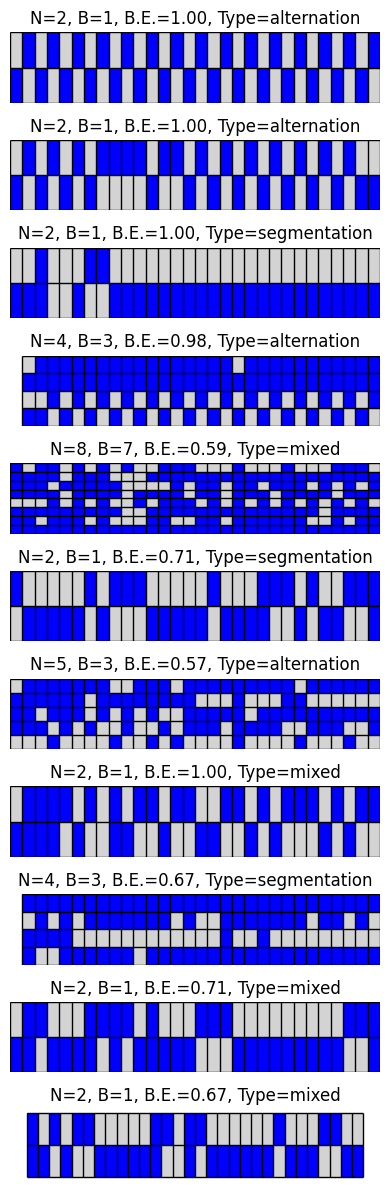

In [12]:
# groups = df_best['model'].unique()
keep_groups_idx = [
    4, 3, 7, 8, 20, 16, 21, 5, 18, 14, 19, # 22
]
groups = np.array(df_best['model'].unique())[keep_groups_idx].tolist()
categories = [
    'alternation', 'alternation', 'segmentation',
    'alternation', 'mixed', 'segmentation',
    'alternation', 'mixed', 'segmentation',
    'mixed', 'mixed', # 'mixed'
]

fig, axes = plt.subplots(
    11, 1, 
    figsize=(4, 12),
    tight_layout=True
)

for i, group in enumerate(groups):
    df_aux = df_best[df_best['model'] == group]
    df_aux_aux = data[data['model'] == group]
    threshold = df_aux['threshold'].unique()[0]
    BE = df_aux['bounded_efficiency'].unique()[0]
    N = df_aux_aux['num_players'].values[0]
    B = int(df_aux_aux['threshold'].values[0] * N)
    # classification = df_aux['predicted_class'].values[0]
    classification = categories[i]
    # classification = i
    bar_renderer = BarRenderer(data=df_aux_aux)
    bar_renderer.render(
        ax=axes[i],
        title=f"N={N}, B={B}, B.E.={BE:.2f}, Type={classification}",
        num_rounds=30
    )


In [13]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig5.png', dpi=300, bbox_inches='tight')